Linear Regression
=================

A multivariate linear regression is fitted to understand the effects of the features on the normalised rank.

In [65]:
import pandas as pd
import dask.dataframe as dd

import imp

plot = imp.load_source('plot', '../src/plot.py')

In [66]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [67]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
features = [
    "CC_to_C_rate",
    "CD_to_C_rate",
    "DC_to_C_rate",
    "DD_to_C_rate",
    "SSE",
    "Cooperation_rating",
    "Cooperation_rating_max",
    "Cooperation_rating_min",
    "Cooperation_rating_median",
    "Cooperation_rating_mean",
    "Cooperation_rating_comp_to_max",
    "Cooperation_rating_comp_to_min",
    "Cooperation_rating_comp_to_median",
    "Cooperation_rating_comp_to_mean",
    "repetitions",
]

In [69]:
dfs = []
for name in ['standard', 'noise', 'probend', 'probend_noise']:
    df = pd.read_csv('../data/%s_3_processed.csv' % name, index_col=0
                           )
    df['type'] = name
    dfs.append(df)

In [70]:
types = ['standard', 'noise', 'probend', 'probend_noise']

In [71]:
dfs[0].head()

,Rank,Name,Median_score,Cooperation_rating,Wins,Initial_C_rate,CC_rate,CD_rate,DC_rate,DD_rate,...,Cooperation_rating_max,Cooperation_rating_min,Cooperation_rating_median,Cooperation_rating_mean,Cooperation_rating_comp_to_max,Cooperation_rating_comp_to_min,Cooperation_rating_comp_to_median,Cooperation_rating_comp_to_mean,memory_usage,type
0,0,Gradual,2.717096,0.796218,2.0,1.0,0.746043,0.050175,0.068898,0.134884,...,1.0,0.0,0.638229,0.619212,0.796218,0.0,1.247542,1.285856,1.000000,standard
1,1,Tit For Tat,2.654342,0.773104,0.0,1.0,0.657263,0.115841,0.113533,0.113363,...,1.0,0.0,0.638229,0.619212,0.773104,0.0,1.211327,1.248529,0.007463,standard
2,2,Forgiving Tit For Tat,2.651289,0.773481,0.0,1.0,0.656839,0.116642,0.113570,0.112949,...,1.0,0.0,0.638229,0.619212,0.773481,0.0,1.211917,1.249137,1.000000,standard
3,3,BackStabber,2.622795,0.644740,8.0,1.0,0.633207,0.011533,0.091880,0.263380,...,1.0,0.0,0.638229,0.619212,0.644740,0.0,1.010202,1.041227,1.000000,standard
4,4,Hard Tit For Tat,2.437585,0.560512,3.0,1.0,0.551061,0.009451,0.086170,0.353319,...,1.0,0.0,0.638229,0.619212,0.560512,0.0,0.878230,0.905202,0.022388,standard


**Standard Tournaments**

In [72]:
max(dfs[0]['turns']), max(dfs[0]['size']), max(dfs[0]['repetitions'])

(200.0, 15.0, 100.0)

In [73]:
a_type = types[0]
df = dfs[0]
    
xs = features.copy()
xs += ["turns", "memory_usage"]

In [74]:
xs.remove('Cooperation_rating')
xs.remove('Cooperation_rating_comp_to_median')
xs.remove('Cooperation_rating_comp_to_max')
xs.remove('Cooperation_rating_median')
xs.remove('DD_to_C_rate')

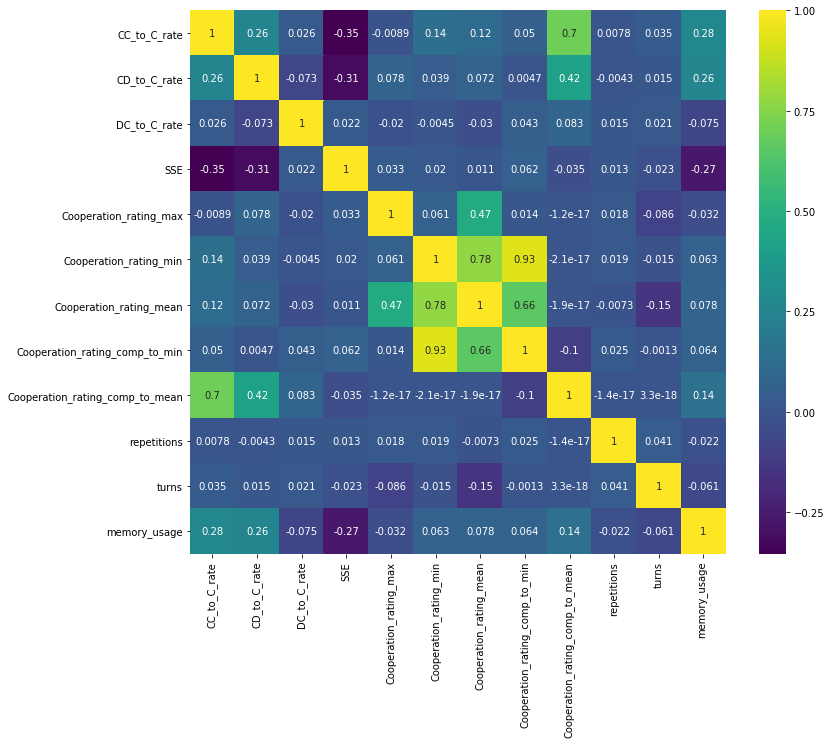

In [75]:
plt.figure(figsize=(12,10))

cor = df[xs].corr()

sns.heatmap(cor, annot=True, cmap="viridis");

In [76]:
features_standard = xs.copy()

In [77]:
X = df[features_standard].values
y = df['Normalized_Rank'].values

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print("============")
print(f"{a_type}")
print("============")
print(model.summary(xname=['constant'] + xs))

standard
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     667.7
Date:                Thu, 22 May 2025   Prob (F-statistic):               0.00
Time:                        13:25:58   Log-Likelihood:                 290.77
No. Observations:                8570   AIC:                            -555.5
Df Residuals:                    8557   BIC:                            -463.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
c

For **standard types** the p-values are smaller than 0.05 thus, all variables have a significant effect. The variabls that affect the most due to higher coefficient values are $C_{max}$, $C_{mean}$, $C_r$ / $C_{mean}$ and $C_r$

**Noisy Tournaments**

In [78]:
index = 1
a_type = types[index]
df = dfs[index]
    
xs = features.copy()
xs += ['noise', 'memory_usage']

In [79]:
xs.remove('Cooperation_rating')
xs.remove('Cooperation_rating_median')
xs.remove('Cooperation_rating_comp_to_median')
xs.remove('Cooperation_rating_max')
xs.remove('DD_to_C_rate')

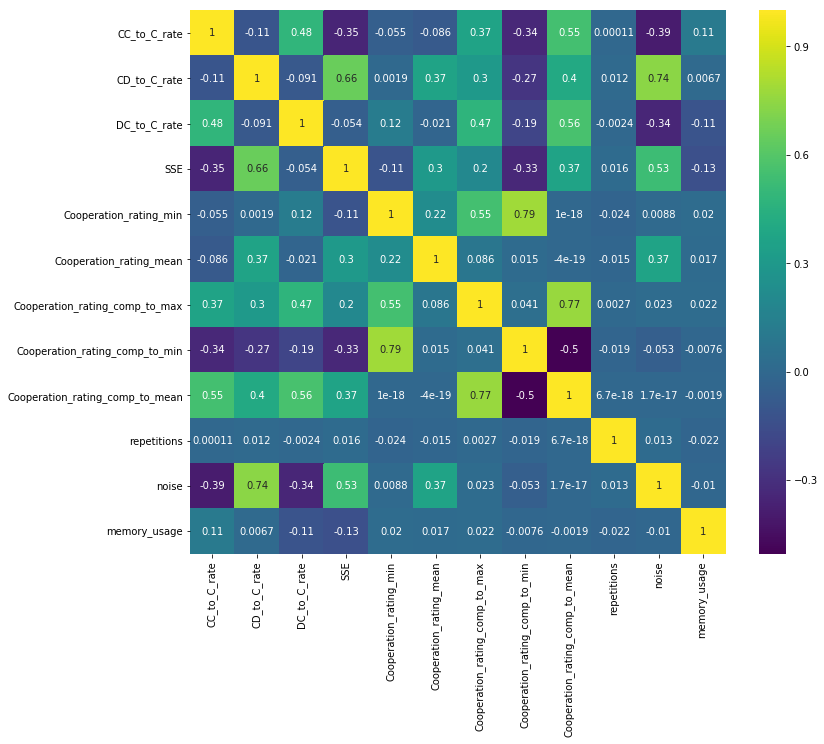

In [80]:
plt.figure(figsize=(12,10))

cor = df[xs].corr()

sns.heatmap(cor, annot=True, cmap="viridis");

In [81]:
features_noisy = xs.copy()

In [82]:
X = df[features_noisy].values
y = df['Normalized_Rank'].values

model = sm.OLS(y, X).fit()

print("============")
print(f"{a_type}")
print("============")
print(model.summary(xname=xs))

noise
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.834
Model:                            OLS   Adj. R-squared (uncentered):              0.834
Method:                 Least Squares   F-statistic:                              3577.
Date:                Thu, 22 May 2025   Prob (F-statistic):                        0.00
Time:                        13:26:00   Log-Likelihood:                         -45.451
No. Observations:                8570   AIC:                                      114.9
Df Residuals:                    8558   BIC:                                      199.6
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------

For **noise types** all expect two feautures are important. The two which are not are _repetitions_ and _memory usage_. The rest of the features have a significant effect. The features with the highest coefficients, both negative and positive, are $C_r$, $C_{max}$, $C_{mean}$ and $C_r$ / $C_{max}$ and with -0.5 $C_r$ / $C_{mean}$

**Probabilistic Ending Tournaments**

In [83]:
index = 2
a_type = types[index]
df = dfs[index]
    
xs = features.copy()
xs += ["probend"]

In [84]:
xs.remove('Cooperation_rating')
xs.remove('Cooperation_rating_median')
xs.remove('Cooperation_rating_comp_to_median')
xs.remove('Cooperation_rating_comp_to_max')
xs.remove('DD_to_C_rate')

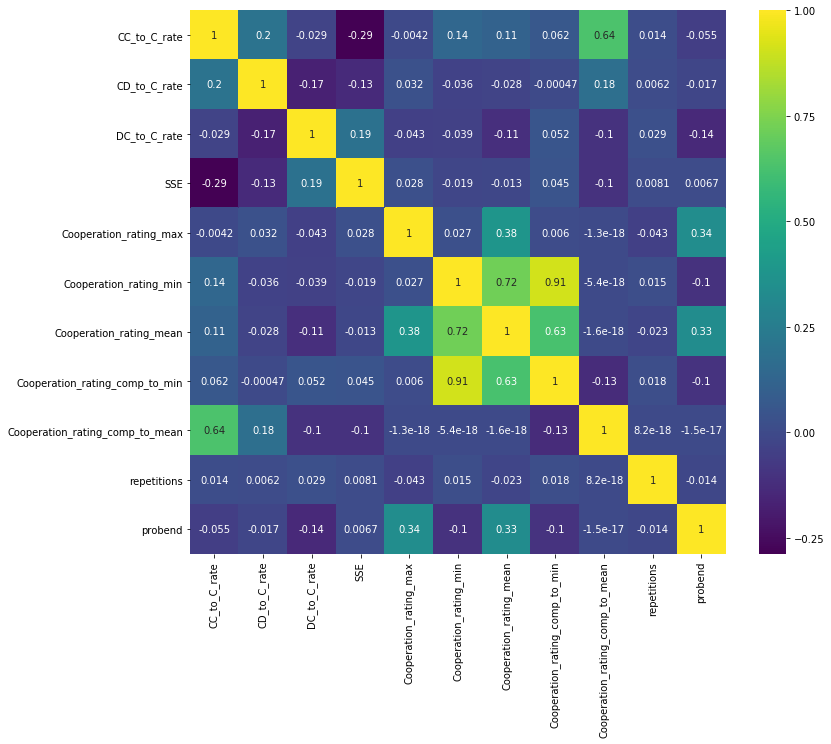

In [85]:
plt.figure(figsize=(12,10))

cor = df[xs].corr()

sns.heatmap(cor, annot=True, cmap="viridis");

In [86]:
features_probend = xs.copy()

In [87]:
X = df[features_probend].values
y = df['Normalized_Rank'].values

model = sm.OLS(y, X).fit()

print("============")
print(f"{a_type}")
print("============")
print(model.summary(xname=xs))

probend
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.861
Model:                            OLS   Adj. R-squared (uncentered):              0.861
Method:                 Least Squares   F-statistic:                              4836.
Date:                Thu, 22 May 2025   Prob (F-statistic):                        0.00
Time:                        13:26:01   Log-Likelihood:                          734.45
No. Observations:                8570   AIC:                                     -1447.
Df Residuals:                    8559   BIC:                                     -1369.
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                                      coef    std err          t      P>|t|      [0.025      0.975]
------------

For **probabilistic ending** tournmanents all but two feautures are significant. The non significant features are size and the probability of the match ending. Regarding the significant features, the once with the highest coefficients positive and negative are: $C_{max}$, $C_{mean}$, $C_r$ / $C_{mean}$, $C_r$ / $C_{max}$

**Noisy Probabilistic Ending Tournaments**

In [88]:
index = 3
a_type = types[index]
df = dfs[index]
    
xs = features.copy()
xs += ["probend", "noise"]

In [89]:
xs.remove('Cooperation_rating')
xs.remove('Cooperation_rating_median')
xs.remove('Cooperation_rating_comp_to_median')
xs.remove('Cooperation_rating_comp_to_min')
xs.remove('Cooperation_rating_min')
xs.remove('noise')
xs.remove('DD_to_C_rate')

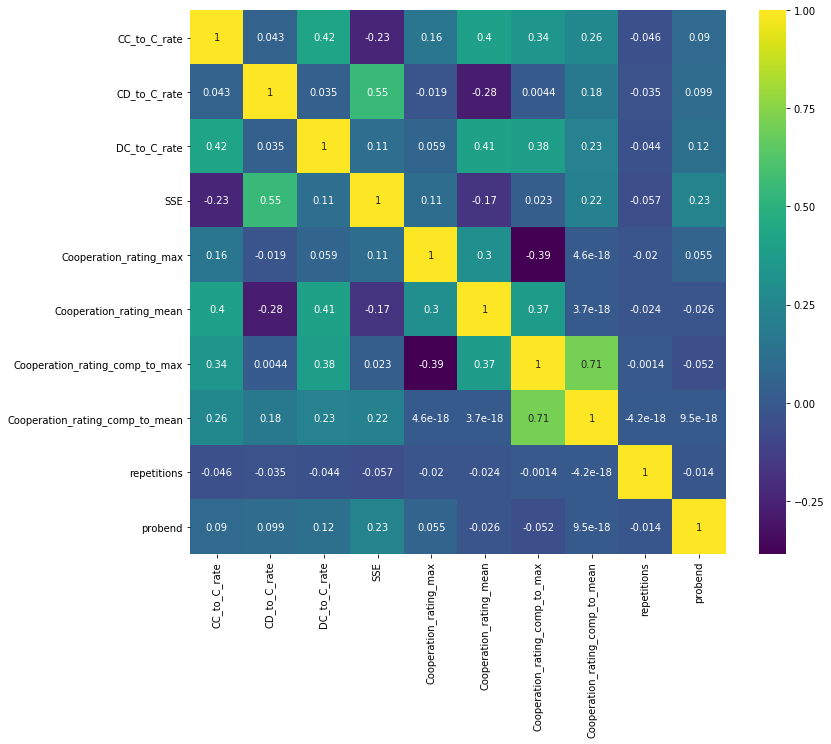

In [90]:
plt.figure(figsize=(12,10))

cor = df[xs].corr()

sns.heatmap(cor, annot=True, cmap="viridis");

In [91]:
features_probend_noisy = xs.copy()

In [92]:
X = df[features_probend_noisy].values
y = df['Normalized_Rank'].values

model = sm.OLS(y, X).fit()

print("============")
print(f"{a_type}")
print("============")
print(model.summary(xname=xs))

probend_noise
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.843
Model:                            OLS   Adj. R-squared (uncentered):              0.843
Method:                 Least Squares   F-statistic:                              4586.
Date:                Thu, 22 May 2025   Prob (F-statistic):                        0.00
Time:                        13:26:02   Log-Likelihood:                          191.48
No. Observations:                8570   AIC:                                     -363.0
Df Residuals:                    8560   BIC:                                     -292.4
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
                                      coef    std err          t      P>|t|      [0.025      0.975]
------

For **noisy probabilistic ending** tournaments all feautures are significant ($p$ value $< 0.5$).  The features with the highest effect on the normalised rank are $C_{max}$, $C_r$ / $C_{max}$, $C_{mean}$.  The effect is now lower than the rest of the tournaments types. 

The $R$s of the models are larger than 0.8 which means that these model explain the 80% of the variance in the data. The models are good.

In [93]:
tables = []
rs = []
for i, xs in enumerate([features_standard, features_noisy, features_probend, features_probend_noisy]):
    df = dfs[i]

    X = df[xs].values
    y = df['Normalized_Rank'].values

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    table = model.summary2(xname=['constant'] + xs)
    rs.append(table.tables[0][2][0] + table.tables[0][3][0])
    table = table.tables[1][['Coef.', 'P>|t|']].round(5)
    table.index = ['constant'] + [plot.features_labels[index] for index in table.index[1:]]
    
    tables.append(table)

In [94]:
pd.concat(tables, axis=1).round(3)

,Coef.,P>|t|,Coef.,P>|t|,Coef.,P>|t|,Coef.,P>|t|
constant,1.029,0.000,0.135,0.001,0.114,0.089,-0.486,0.000
$CC$ to $C$ rate,-0.081,0.000,0.248,0.000,-0.010,0.318,0.025,0.035
$CD$ to $C$ rate,0.268,0.000,-0.043,0.044,0.110,0.000,0.026,0.028
$DC$ to $C$ rate,-0.045,0.000,-0.109,0.000,-0.114,0.000,-0.036,0.001
SSE,0.078,0.000,0.224,0.000,-0.033,0.000,0.025,0.005
$C_{max}$,-0.289,0.000,NaN,NaN,0.011,0.889,1.259,0.000
$C_{min}$,-0.483,0.000,-0.125,0.052,0.231,0.000,NaN,NaN
$C_{mean}$,0.428,0.000,-0.292,0.000,-0.111,0.038,-1.579,0.000
$C_{min}$ / $C_r$,0.289,0.000,-0.188,0.000,-0.176,0.000,NaN,NaN
$C_r$ / $C_{mean}$,-0.429,0.000,0.069,0.042,0.503,0.000,-0.122,0.000


In [95]:
file = open('../paper/regression_results.tex', "w")
table_to_write = pd.concat(tables, axis=1).round(3).to_latex().replace('\$', '$').replace('\_', '_').replace('NaN', '  -')
file.write(table_to_write.replace('\{', '{').replace('\}', '}'))
file.close()

In [96]:
rs

['Adj. R-squared:0.483',
 'Adj. R-squared:0.441',
 'Adj. R-squared:0.534',
 'Adj. R-squared:0.500']